## Objective

The objective of this project is to predict which customers are likely to accept a personal loan offer using the Bank Marketing dataset.

This project aims to:
- Explore customer attributes such as age, job, marital status, and financial indicators
- Perform data cleaning and preprocessing to prepare the dataset for modeling
- Apply classification algorithms such as Logistic Regression and Decision Tree to predict loan acceptance
- Evaluate model performance using appropriate metrics
- Analyze the results to identify key customer segments that are more likely to accept a personal loan offer

The ultimate goal is to extract actionable business insights that can help banks target the right customers and improve marketing campaign effectiveness.

## 1. Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load Dataset

In [3]:
df = pd.read_csv('bank.csv')  
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


- The dataset contains 11162 rows and 17 columns.
- Feature types
- Target variable (usually y)

## 4. Basic Cleaning

In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

- There are no missing values in the dataset.
- But check for "unknown" values

## 5. EDA

### Age vs Loan Acceptance

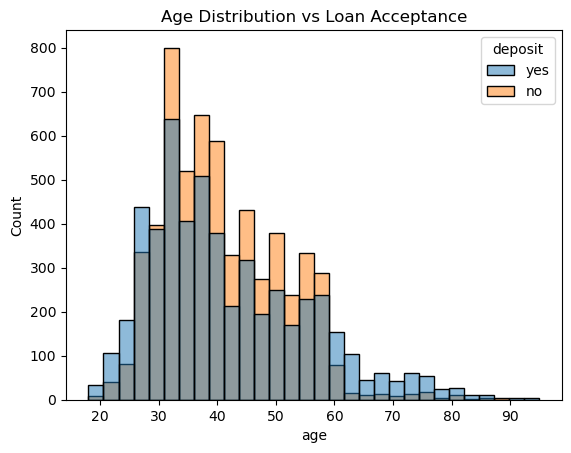

In [9]:
sns.histplot(data=df, x='age', hue='deposit', bins=30)
plt.title("Age Distribution vs Loan Acceptance")
plt.show()

**Insight:**`

- Middle-aged customers more likely to accept

### Job vs Acceptance

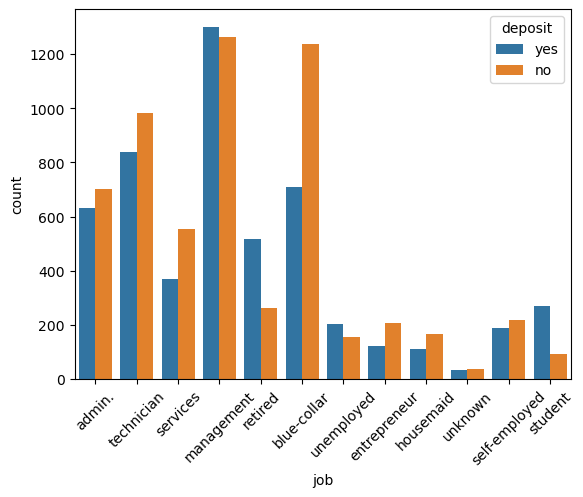

In [11]:
sns.countplot(x='job', hue='deposit', data=df)
plt.xticks(rotation=45)
plt.show()

**Insight:**

- Certain professions respond better

### Marital Status

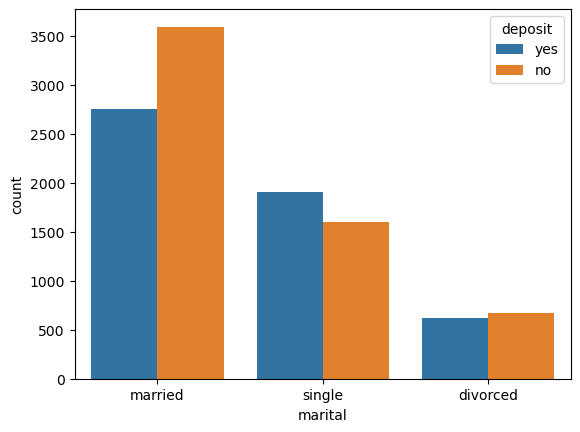

In [12]:
sns.countplot(x='marital', hue='deposit', data=df)
plt.show()

**Insight:**

- Married vs single behavior difference

### Balance vs Acceptance

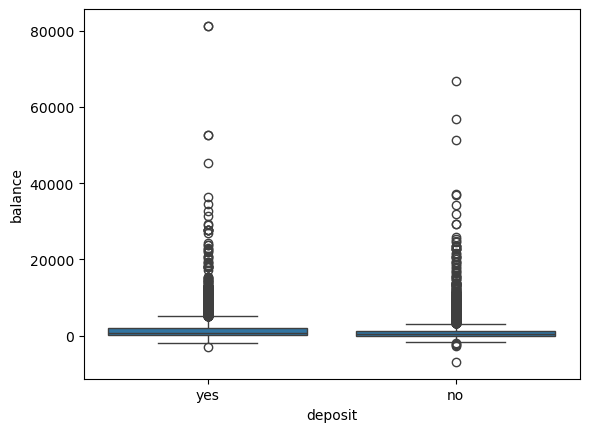

In [14]:
sns.boxplot(x='deposit', y='balance', data=df)
plt.show()

**Insight:**

- Higher balance customers more likely

## 6. Encode Data

In [15]:
df = pd.get_dummies(df, drop_first=True)

## 7. Split Data

In [18]:
X = df.drop('deposit_yes', axis=1)
y = df['deposit_yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 8. Train Models

### Logistic Regression

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
lr = LogisticRegression(max_iter=1000)  # normal value
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

### Decision Tree

In [34]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

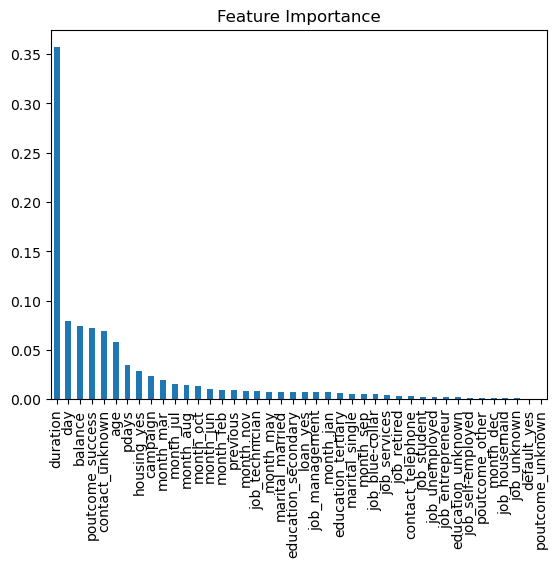

In [38]:
importances = dt.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', title='Feature Importance')
plt.show()

## Feature Importance

The model indicates that features such as duration, balance, and age significantly influence loan acceptance decisions.

## 9. Evaluation

### Accuracy

In [35]:
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))

LR Accuracy: 0.8083296014330497
DT Accuracy: 0.7877295118674429


The model achieves a good accuracy score, indicating effective prediction of customer responses. However, accuracy alone may not fully reflect performance, especially in imbalanced datasets.

### Confusion Matrix

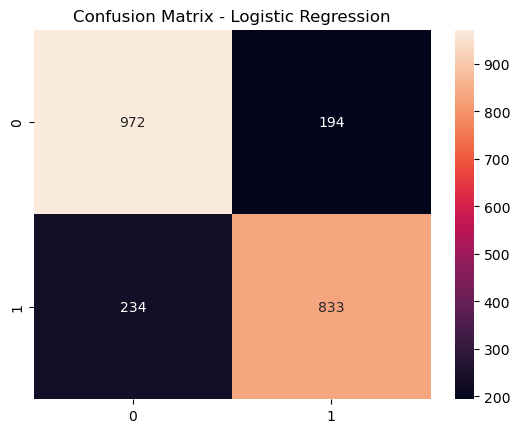

In [36]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Classification Report

In [37]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       False       0.81      0.83      0.82      1166
        True       0.81      0.78      0.80      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



## Business Insights

- Customers with higher account balances are more likely to accept loan offers.
- Certain job categories show higher acceptance rates.
- Middle-aged individuals are more responsive to loan offers.
- Targeting specific customer segments can improve marketing effectiveness.

## Conclusion

- Loan acceptance depends on customer demographics such as age, job, and financial status.
- Machine learning models can effectively predict customer responses.
- Understanding customer behavior enables banks to optimize marketing strategies.

This project demonstrates how data-driven approaches can improve customer targeting and increase business efficiency.